In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Data Collection

In [2]:
from datetime import datetime

now = datetime.now()

start=datetime(now.year-10,now.month,now.day)
end=now
ticker = 'AAPL'
df = yf.download(ticker,start,end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-16,21.371748,21.487850,20.864090,21.032550,245039200
2016-05-17,21.282963,21.558419,21.173692,21.524273,187667600
2016-05-18,21.526550,21.674523,21.374025,21.435492,168249600
2016-05-19,21.444588,21.544754,21.301169,21.544754,121768400
2016-05-20,21.676804,21.724610,21.517448,21.544766,128104000
...,...,...,...,...,...
2026-05-08,293.050018,294.488695,289.733067,289.743067,52692800
2026-05-11,292.679993,293.880005,290.230011,291.980011,42247300


In [ ]:
# df.head()

In [ ]:
# df.tail()

# 2. Data Exploration and Vizualization

In [ ]:
type(df)
df.shape
df.isna().sum()

In [3]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,122.913846,124.136423,121.572711,122.799521,9.690136e+07
std,76.198651,76.931195,75.398164,76.129282,5.492964e+07
min,20.952875,21.182802,20.829944,21.032550,5.534221e+06
25%,44.807575,45.140816,44.312708,44.665667,5.761422e+07
50%,128.470398,130.335588,127.166855,128.754367,8.504700e+07
75%,179.102806,180.746278,176.797765,178.933962,1.178710e+08
max,298.869995,300.920013,297.079987,299.820007,4.479400e+08


In [ ]:
df.dtypes

In [4]:
# Reset Index to Integer rather than date
df = df.reset_index()

In [ ]:
# df.head()

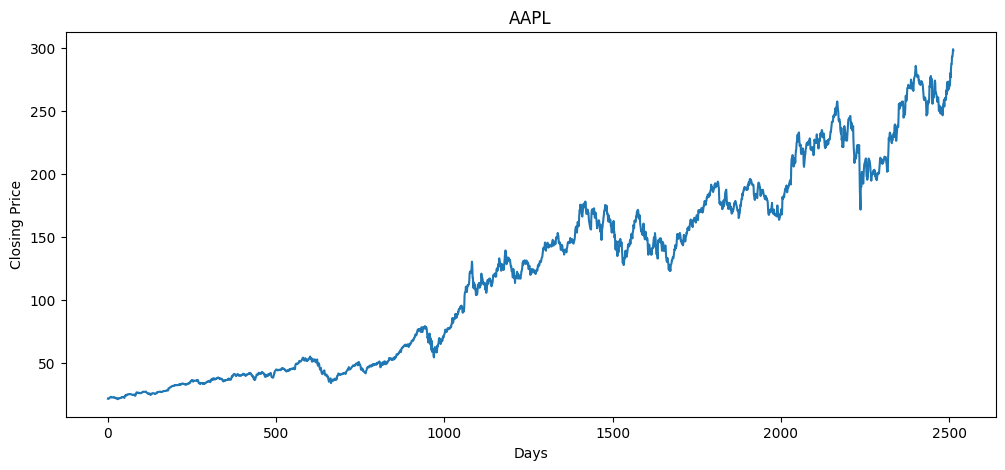

In [5]:
plt.figure(figsize = (12,5))
plt.plot(df.Close);
plt.title(ticker);
plt.xlabel('Days');
plt.ylabel ('Closing Price');

# 3. Feature Engineering

In [6]:
df1=pd.DataFrame(df.Close);
df1

Ticker,AAPL
0,21.371748
1,21.282963
2,21.526550
3,21.444588
4,21.676804
...,...
2509,293.050018
2510,292.679993
2511,294.799988
2512,298.869995


In [7]:
# Calculating the moving average for 50 days
df1['MA_100'] = df.Close.rolling(100).mean()
df1.head(200)

Ticker,AAPL,MA_100
0,21.371748,NaN
1,21.282963,NaN
2,21.526550,NaN
3,21.444588,NaN
4,21.676804,NaN
...,...,...
195,31.546007,27.078525
196,31.576040,27.135533
197,31.638420,27.194379
198,31.652285,27.252264


Text(0, 0.5, 'Price')

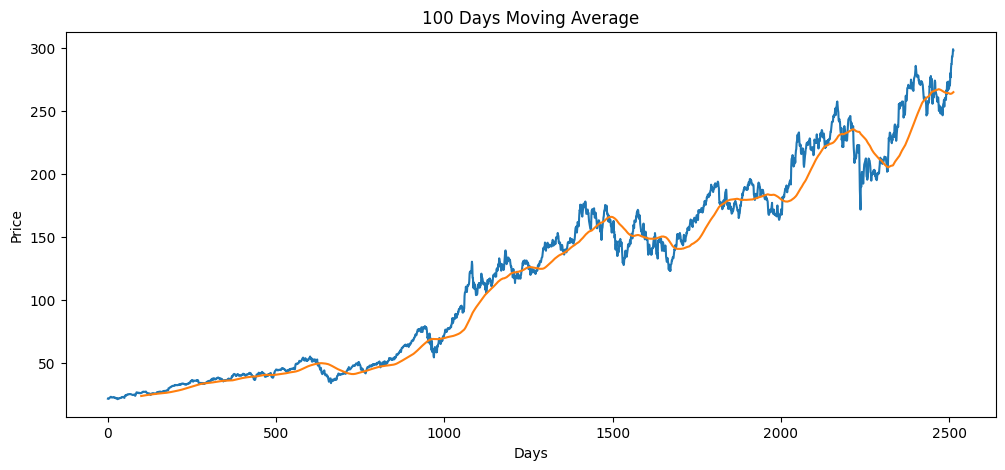

In [8]:
plt.figure(figsize =(12,5))
plt.plot(df.Close);
plt.plot(df1['MA_100']);
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

# 200 Days Moving Average

In [9]:
#df1
df1['MA_200'] = df.Close.rolling(200).mean()
df1

Ticker,AAPL,MA_100,MA_200
0,21.371748,NaN,NaN
1,21.282963,NaN,NaN
2,21.526550,NaN,NaN
3,21.444588,NaN,NaN
4,21.676804,NaN,NaN
...,...,...,...
2509,293.050018,263.855202,256.516398
2510,292.679993,264.045985,256.915221
2511,294.799988,264.252978,257.324047
2512,298.869995,264.528319,257.752376


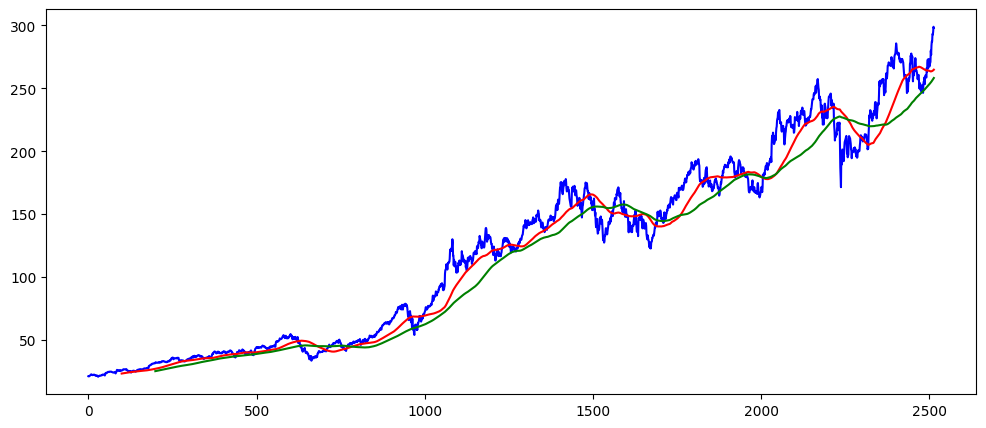

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df.Close,color='blue');
plt.plot(df1['MA_100'],color='red');
plt.plot(df1['MA_200'],color='green');

In [11]:
# Percentage change in stock price everyday
df1['percentage_change'] = df.Close.pct_change()
df1

Ticker,AAPL,MA_100,MA_200,percentage_change
0,21.371748,NaN,NaN,NaN
1,21.282963,NaN,NaN,-0.004154
2,21.526550,NaN,NaN,0.011445
3,21.444588,NaN,NaN,-0.003808
4,21.676804,NaN,NaN,0.010829
...,...,...,...,...
2509,293.050018,263.855202,256.516398,0.020456
2510,292.679993,264.045985,256.915221,-0.001263
2511,294.799988,264.252978,257.324047,0.007243
2512,298.869995,264.528319,257.752376,0.013806


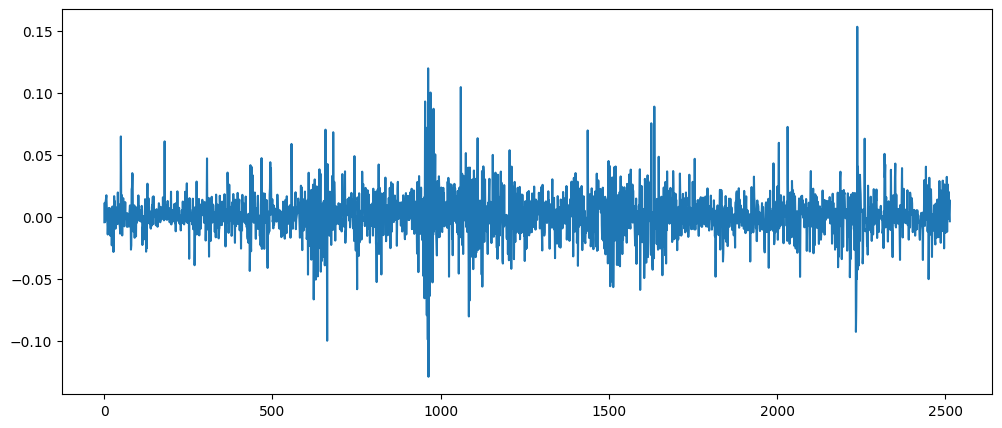

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df1.percentage_change)

# 4. Data Preprocessing

In [13]:
# Splitting Data into Training and Testing Datasets

data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
print(data_training)
type(data_training)

Ticker        AAPL
0        21.371748
1        21.282963
2        21.526550
3        21.444588
4        21.676804
...            ...
1754    163.272018
1755    170.933899
1756    170.864960
1757    169.161240
1758    170.924042

[1759 rows x 1 columns]


pandas.DataFrame

In [14]:
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):len(df)])
print(data_testing)

Ticker        AAPL
1759    171.111176
1760    170.184158
1761    169.691116
1762    169.691116
1763    170.302490
...            ...
2509    293.050018
2510    292.679993
2511    294.799988
2512    298.869995
2513    297.864990

[755 rows x 1 columns]


In [15]:
# Scaling down Data into a range of 0 and 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1));
training_data_array = scaler.fit_transform(data_training)
print(training_data_array)

training_data_array.shape
type(training_data_array)

[[0.0026682 ]
 [0.00210265]
 [0.00365429]
 ...
 [0.95493392]
 [0.94408129]
 [0.95531027]]


numpy.ndarray

In [16]:
# Creating Data Sequence
# Tomorrow's stock price is dependent on previous days stock price
# 1,2,3,4,5,6 --> X_train && 7 --> Y_train

X_train = []
Y_train = []

for i in range(100,training_data_array.shape[0]):
    X_train.append(training_data_array[i-100:i])
    Y_train.append(training_data_array[i, 0])
    



In [17]:
x_train = np.array(X_train)
x_train

array([[[0.0026682 ],
        [0.00210265],
        [0.00365429],
        ...,
        [0.03058231],
        [0.03128214],
        [0.03135508]],

       [[0.00210265],
        [0.00365429],
        [0.00313219],
        ...,
        [0.03128214],
        [0.03135508],
        [0.03257973]],

       [[0.00365429],
        [0.00313219],
        [0.00461139],
        ...,
        [0.03135508],
        [0.03257973],
        [0.03282762]],

       ...,

       [[0.77156615],
        [0.77770449],
        [0.76354859],
        ...,
        [0.91698087],
        [0.90656719],
        [0.95537306]],

       [[0.77770449],
        [0.76354859],
        [0.72151945],
        ...,
        [0.90656719],
        [0.95537306],
        [0.95493392]],

       [[0.76354859],
        [0.72151945],
        [0.7090547 ],
        ...,
        [0.95537306],
        [0.95493392],
        [0.94408129]]], shape=(1659, 100, 1))

In [18]:
y_train = np.array(Y_train)
y_train

array([0.03257973, 0.03282762, 0.03572898, ..., 0.95493392, 0.94408129,
       0.95531027], shape=(1659,))

In [ ]:
# X_train, Y_train = np.array(X_train), np.array(Y_train)

In [ ]:
x_train.ndim
type(x_train)
x_train.shape

In [ ]:
y_train.shape

# 6. Model Building

### Training the LSTM Model 

In [ ]:
import tensorflow as tf
 print(tf.__version__ )



: 

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM,Input

In [ ]:
model = Sequential()
model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation = 'tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))